In [5]:
# Solar Power Generation - Regression

## 1. Introduction
# The objective of this project is to develop machine learning regression models
# for predicting solar power generation using the Solar Power Generation dataset.
# The project includes data exploration, preprocessing, feature engineering,
# model training, model comparison, hyperparameter tuning, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
generation_1 = pd.read_csv("../data/solar/Plant_1_Generation_Data.csv")
weather_1 = pd.read_csv("../data/solar/Plant_1_Weather_Sensor_Data.csv")

generation_2 = pd.read_csv("../data/solar/Plant_2_Generation_Data.csv")
weather_2 = pd.read_csv("../data/solar/Plant_2_Weather_Sensor_Data.csv")

print("Plant 1 Generation:", generation_1.shape)
print("Plant 1 Weather:", weather_1.shape)
print("Plant 2 Generation:", generation_2.shape)
print("Plant 2 Weather:", weather_2.shape)

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)


In [3]:
generation_1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
generation_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [5]:
generation_1.describe()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


In [6]:
generation_1.isnull().sum()

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [7]:
generation_1.duplicated().sum()

np.int64(0)

In [8]:
generation_1.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

In [9]:
generation_1["AC_POWER"].describe()

count    68778.000000
mean       307.802752
std        394.396439
min          0.000000
25%          0.000000
50%         41.493750
75%        623.618750
max       1410.950000
Name: AC_POWER, dtype: float64

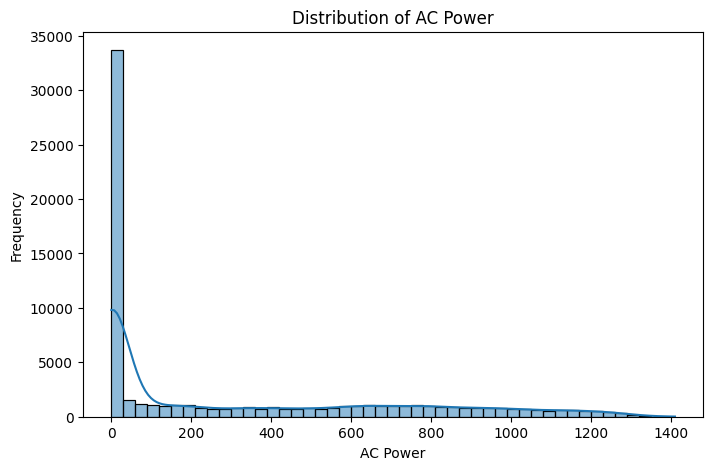

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(generation_1["AC_POWER"], kde=True)
plt.title("Distribution of AC Power")
plt.xlabel("AC Power")
plt.ylabel("Frequency")
plt.show()

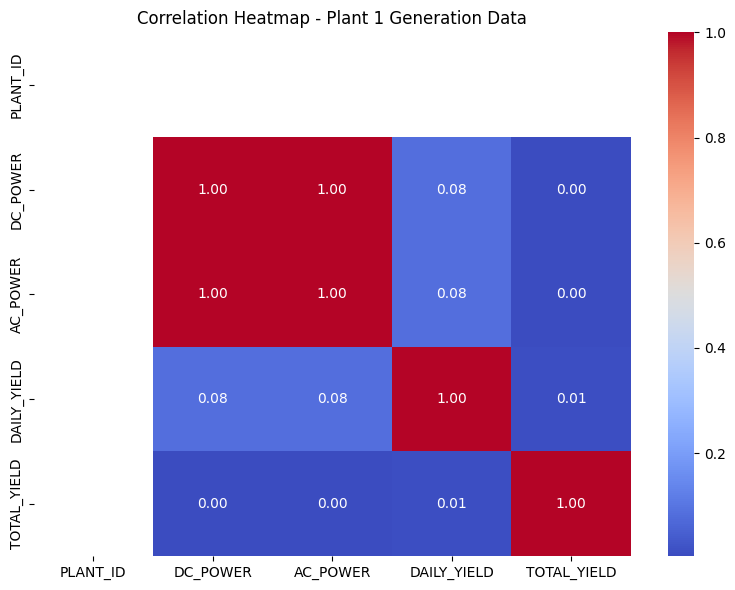

In [10]:
plt.figure(figsize=(8, 6))

numeric_data = generation_1.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Plant 1 Generation Data")
plt.tight_layout()
plt.show()

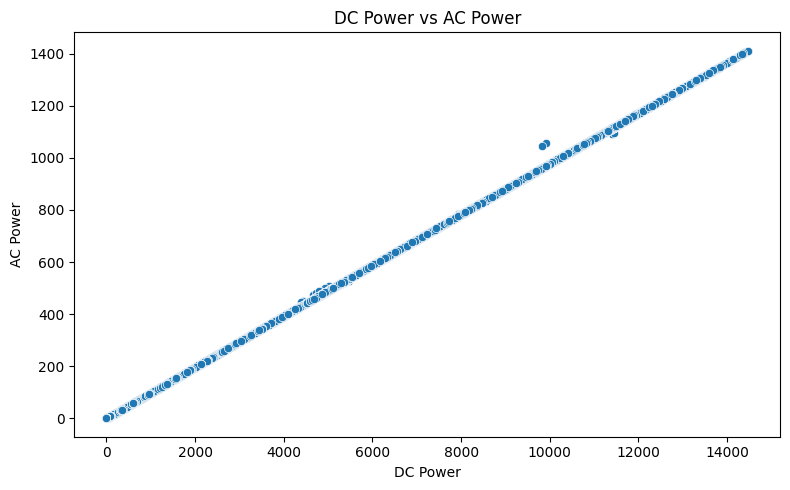

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=generation_1,
    x="DC_POWER",
    y="AC_POWER"
)

plt.title("DC Power vs AC Power")
plt.xlabel("DC Power")
plt.ylabel("AC Power")
plt.tight_layout()
plt.show()

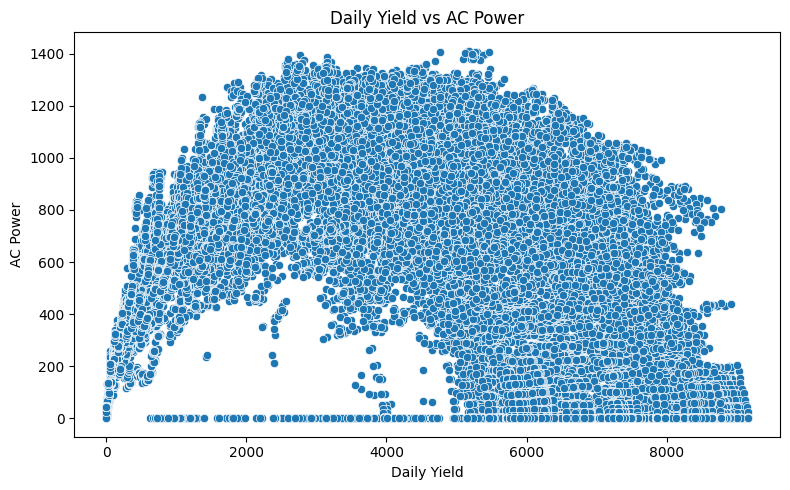

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=generation_1,
    x="DAILY_YIELD",
    y="AC_POWER"
)

plt.title("Daily Yield vs AC Power")
plt.xlabel("Daily Yield")
plt.ylabel("AC Power")
plt.tight_layout()
plt.show()

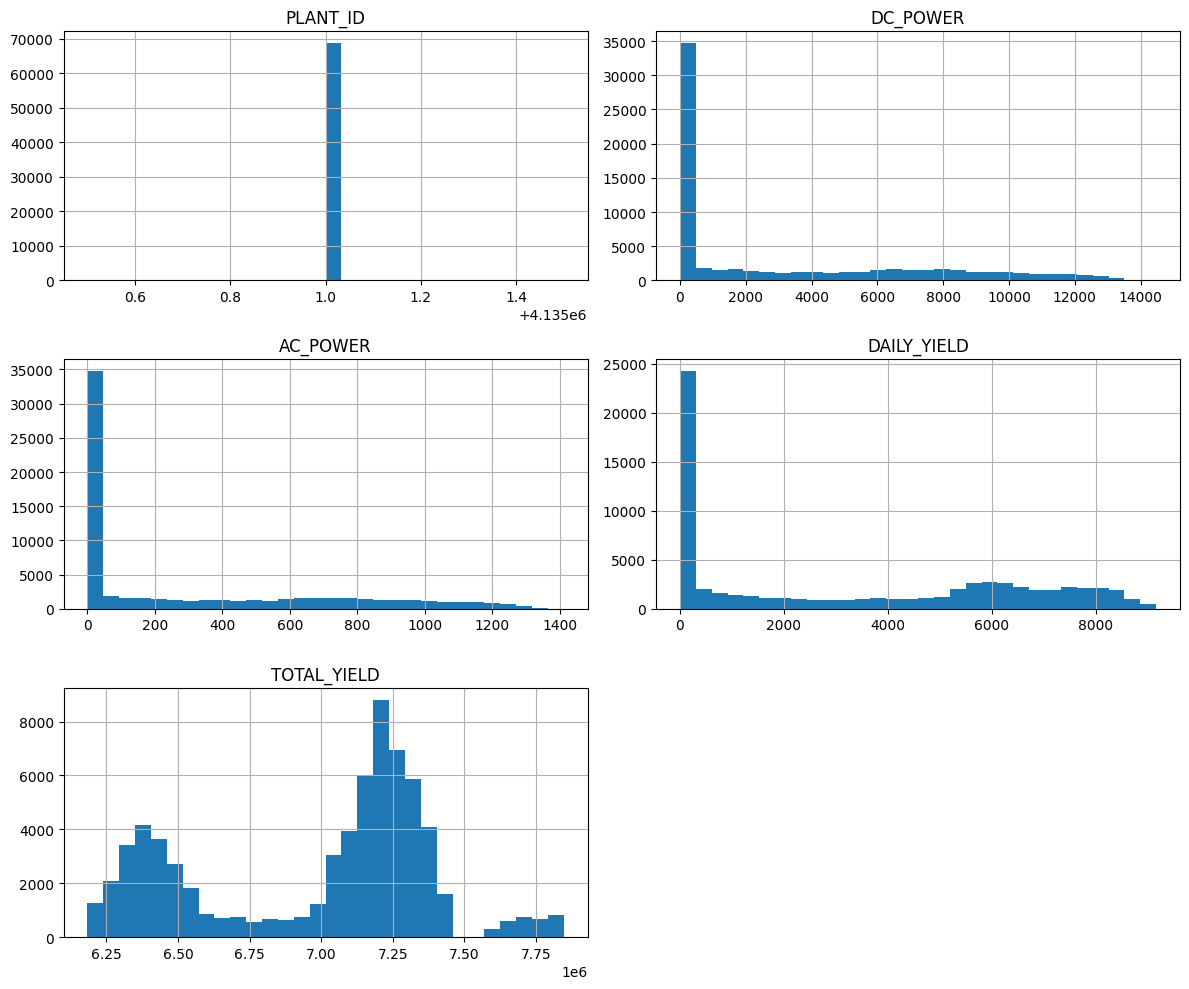

In [15]:
generation_1[numeric_data.columns].hist(
    figsize=(12, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [16]:
## 3. Data Cleaning and Preprocessing

df = generation_1.copy()

print("Original shape:", df.shape)
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Original shape: (68778, 7)
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
Duplicate rows: 0


In [17]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (68778, 7)


In [19]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

print(df["DATE_TIME"].dtype)
df["hour"] = df["DATE_TIME"].dt.hour
df["day"] = df["DATE_TIME"].dt.day
df["month"] = df["DATE_TIME"].dt.month
df["day_of_week"] = df["DATE_TIME"].dt.dayofweek

datetime64[ns]


In [20]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month,day_of_week
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,0,15,5,4
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,0,15,5,4
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,0,15,5,4
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,0,15,5,4
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,0,15,5,4


In [21]:
df.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month,day_of_week
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000,68778.000000,68778.000000,68778.000000
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,11.567216,15.762133,5.518567,2.991160
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,0.000000,1.000000,5.000000,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,6.000000,9.000000,5.000000,1.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,12.000000,16.000000,6.000000,3.000000
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,17.000000,23.000000,6.000000,5.000000
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,23.000000,31.000000,6.000000,6.000000
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,6.862477,8.554765,0.499659,2.058307


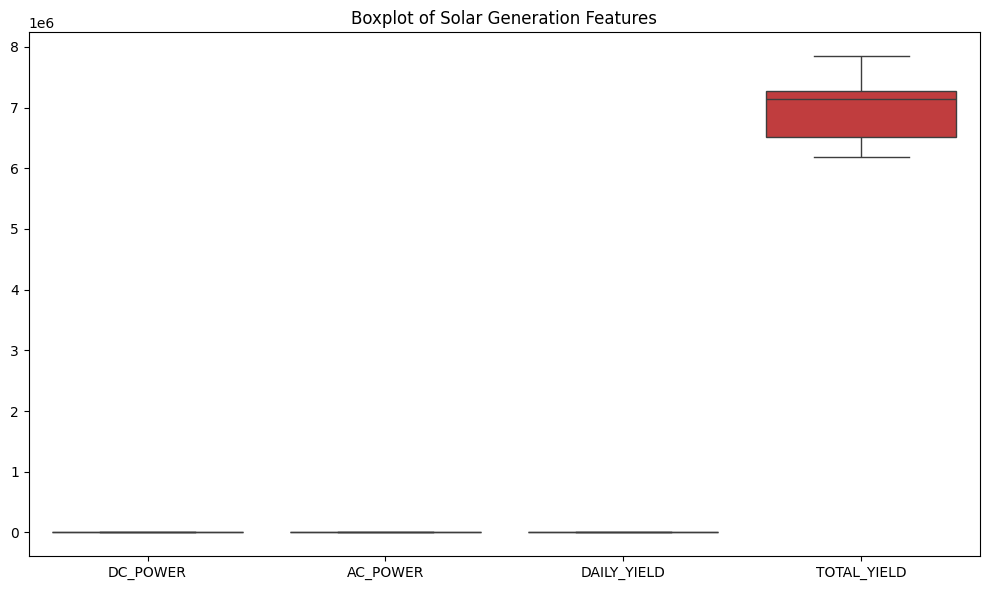

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]])

plt.title("Boxplot of Solar Generation Features")
plt.tight_layout()
plt.show()

In [23]:
y = df["AC_POWER"]

In [24]:
# Target variable
y = df["AC_POWER"]

# Input features
X = df[
    [
        "DC_POWER",
        "DAILY_YIELD",
        "TOTAL_YIELD",
        "hour",
        "day",
        "month",
        "day_of_week"
    ]
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (68778, 7)
y shape: (68778,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (55022, 7)
X_test: (13756, 7)
y_train: (55022,)
y_test: (13756,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": SVR(C=1.0, kernel="rbf"),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

print("Models created:", len(models))

Models created: 9


In [29]:
results = []

for name, model in models.items():

    # Use scaled data for models sensitive to feature scale
    if name in ["SVR", "KNN", "Ridge Regression", "Lasso Regression", "ElasticNet"]:
        Xtr = X_train_scaled
        Xte = X_test_scaled
    else:
        Xtr = X_train
        Xte = X_test

    model.fit(Xtr, y_train)

    predictions = model.predict(Xte)

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest,0.999991,1.156750,0.143945
1,Decision Tree,0.999991,1.190071,0.179896
2,Linear Regression,0.999986,1.461325,0.714509
3,Ridge Regression,0.999986,1.461417,0.717655
4,Lasso Regression,0.999986,1.461424,0.715381
5,ElasticNet,0.999986,1.480359,0.805702
6,Gradient Boosting,0.999964,2.363176,1.173769
7,KNN,0.997854,18.208686,9.648766
8,SVR,0.988867,41.478739,20.642540


In [30]:
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train_scaled, y_train)

poly_predictions = poly_model.predict(X_test_scaled)

poly_r2 = r2_score(y_test, poly_predictions)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_predictions))
poly_mae = mean_absolute_error(y_test, poly_predictions)

print("Polynomial Regression")
print("R2   :", poly_r2)
print("RMSE :", poly_rmse)
print("MAE  :", poly_mae)

Polynomial Regression
R2   : 0.9999910602824267
RMSE : 1.1753737341050263
MAE  : 0.2711604333595939


In [31]:
results.append({
    "Model": "Polynomial Regression",
    "R2": poly_r2,
    "RMSE": poly_rmse,
    "MAE": poly_mae
})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest,0.999991,1.156750,0.143945
1,Polynomial Regression,0.999991,1.175374,0.271160
2,Decision Tree,0.999991,1.190071,0.179896
3,Linear Regression,0.999986,1.461325,0.714509
4,Ridge Regression,0.999986,1.461417,0.717655
5,Lasso Regression,0.999986,1.461424,0.715381
6,ElasticNet,0.999986,1.480359,0.805702
7,Gradient Boosting,0.999964,2.363176,1.173769
8,KNN,0.997854,18.208686,9.648766
9,SVR,0.988867,41.478739,20.642540


In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


rf_cv_scores = cross_val_score(
    models["Random Forest"],
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Random Forest - 5 Fold CV R²")
print("Scores:", rf_cv_scores)
print("Mean CV R²:", rf_cv_scores.mean())



poly_cv_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_cv_scores = cross_val_score(
    poly_cv_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("\nPolynomial Regression - 5 Fold CV R²")
print("Scores:", poly_cv_scores)
print("Mean CV R²:", poly_cv_scores.mean())

Random Forest - 5 Fold CV R²
Scores: [0.99999887 0.9999992  0.99999915 0.99999945 0.99999895]
Mean CV R²: 0.9999991238626544

Polynomial Regression - 5 Fold CV R²
Scores: [0.99999858 0.99999893 0.99999891 0.99999923 0.99999873]
Mean CV R²: 0.9999988769143382


In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [34]:
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Best CV R²:
0.9999991329792779
